In [1]:
import pandas as pd
print(pd.__version__)

3.0.3


In [2]:
df = pd.read_csv("../data/ecommerce.csv", encoding="ISO-8859-1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 541909
Columns : 8


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df = df.dropna(subset=["CustomerID"])

df = df[df["Quantity"] > 0]

df = df[df["UnitPrice"] > 0]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [7]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

In [8]:
print("Total Revenue :", round(df["Revenue"].sum(),2))

print("Unique Customers :", df["CustomerID"].nunique())

print("Total Transactions :", df["InvoiceNo"].nunique())

Total Revenue : 8911407.9
Unique Customers : 4338
Total Transactions : 18532


## __RFM ANALYSIS__

In [9]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [10]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [12]:
rfm["R_score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

rfm["M_score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [13]:
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112


In [14]:
def segment_customer(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4:
        return "Champions"

    elif row["R_score"] >= 3 and row["F_score"] >= 3:
        return "Loyal Customers"

    elif row["R_score"] >= 4:
        return "Potential Loyalists"

    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk"

    else:
        return "Lost Customers"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,Lost Customers
12347.0,2,7,4310.00,5,5,5,555,Champions
12348.0,75,4,1797.24,2,4,4,244,At Risk
12349.0,19,1,1757.55,4,1,4,414,Potential Loyalists
12350.0,310,1,334.40,1,1,2,112,Lost Customers


In [15]:
rfm["Segment"].value_counts()

Segment
Lost Customers         1416
Champions              1139
Loyal Customers         821
At Risk                 643
Potential Loyalists     319
Name: count, dtype: int64

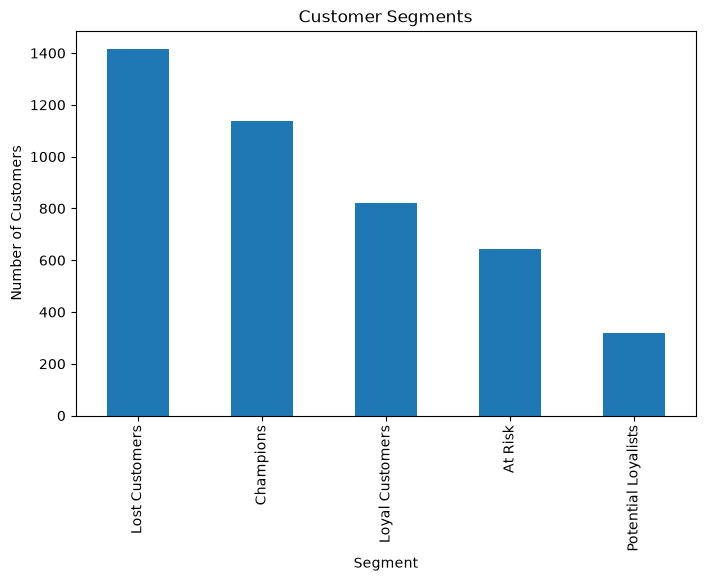

In [16]:
import matplotlib.pyplot as plt

segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(8,5))
segment_counts.plot(kind="bar")
plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

In [17]:
rfm.to_csv("../data/rfm_data.csv")